# Multi-class semantic annotation of SpatialData images

This notebook walks through the full workflow for interactively annotating a
multichannel, multiscale SpatialData image and storing the result back into
the same object.

**Steps**
1. Install dependencies & imports
2. Build (or load) a SpatialData object
3. Inspect the image element
4. **Option A** – pixel-level painting with a Labels layer
5. **Option B** – polygon drawing with a Shapes layer
6. Export the annotation back into `sdata`
7. Rasterize shapes → labels (Option B only)
8. Save to Zarr / write individual elements
9. Reload and verify

> **Tip:** Run cells top-to-bottom. The napari window will block execution
> (via `napari.run()`) until you close it.

## 1. Install dependencies

Run once per environment, then restart the kernel.

## 2. Imports

In [ ]:
%gui qt

from __future__ import annotations

import numpy as np
import spatialdata
import spatialdata_plot

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parents[1]))

from annotate_sdata import (
    open_in_napari,
    add_labels_layer,
    add_shapes_layer,
    labels_layer_to_sdata,
    shapes_layer_to_sdata,
    rasterize_shapes_to_labels,
    run_annotation_session,
    measure_label_morphology,
    labels_to_shapes,
    load_labels_for_refinement,
    run_refinement_session,
)
from sdata_utils import (
    get_scale0_xarray,
    get_scale0_shape,
    get_channel_names,
    class_id_colormap,
    print_sdata_summary,
)

## 3. Build (or load) a SpatialData object

**Option A – demo data (no file needed):** run the cell below to generate a synthetic 4-channel, multiscale image.
```python

def make_demo_sdata(
    height: int = 512, width: int = 512, n_channels: int = 4
) -> spatialdata.SpatialData:
    """Create a toy multichannel, multiscale SpatialData object."""
    rng = np.random.default_rng(42)
    data = rng.integers(0, 2**16, size=(n_channels, height, width), dtype=np.uint16)
    channel_names = ["DAPI", "Marker-A", "Marker-B", "Marker-C"][:n_channels]
    image = Image2DModel.parse(
        data,
        dims=["c", "y", "x"],
        c_coords=channel_names,
        scale_factors=[2, 2],  # full → ½ → ¼ resolution pyramid
    )
    return spatialdata.SpatialData(images={"image": image})


# ----- create / load -----
sdata = make_demo_sdata()
# sdata = spatialdata.read_zarr("path/to/your.zarr")  # ← uncomment to load from disk

print(sdata)
```
**Option B – load from disk:** replace the `make_demo_sdata()` call with  
```python
sdata = spatialdata.read_zarr("path/to/your.zarr")
```

In [3]:
DONOR_ID = "17825"
SAMPLE_ID = f"{DONOR_ID}_300_processed_015"

SAMPLE_PATH = f"G:/GROVe/processed/spatialdata_objects/{DONOR_ID}/SpatialData_{SAMPLE_ID}.zarr"

print(SAMPLE_PATH)

G:/GROVe/processed/spatialdata_objects/17825/SpatialData_17825_300_processed_015.zarr


In [4]:
from spatialdata.models import Image2DModel
import spatialdata_io

sdata = spatialdata.read_zarr(SAMPLE_PATH)

print(sdata)

SpatialData object, with associated Zarr store: G:\GROVe\processed\spatialdata_objects\17825\SpatialData_17825_300_processed_015.zarr
├── Images
│     └── 'raw': DataTree[cyx] (5, 14636, 30506), (5, 7318, 15253), (5, 3659, 7626), (5, 1829, 3813)
└── Points
      └── 'joint_centroids': DataFrame with shape: (<Delayed>, 3) (2D points)
with coordinate systems:
    ▸ 'global', with elements:
        raw (Images), joint_centroids (Points)


C:\Users\mcowan\AppData\Local\Temp\ipykernel_58348\2120420689.py:4: UserWarning: SpatialData is not stored in the most current format. If you want to use Zarr v3, please write the store to a new location using `sdata.write()`.
  sdata = spatialdata.read_zarr(SAMPLE_PATH)
c:\Users\mcowan\Documents\napari_spatial_data\.venv\Lib\site-packages\zarr\core\group.py:3535: ZarrUserWarning: Object at zmetadata is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


## 4. Inspect the image element

In [5]:
IMAGE_KEY = "raw"  # change if your image has a different key

h, w = get_scale0_shape(sdata, IMAGE_KEY)
channels = get_channel_names(sdata, IMAGE_KEY)

print(f"Image key  : {IMAGE_KEY!r}")
print(f"Resolution : {h} × {w}  (height × width)")
print(f"Channels   : {channels}")
print()
print_sdata_summary(sdata)

Image key  : 'raw'
Resolution : 14636 × 30506  (height × width)
Channels   : ['0', '1', '2', '3', '4']

SpatialData summary

[images]
  'raw'                          → {'c': 5, 'y': 14636, 'x': 30506}

[points]
  'joint_centroids'              → <class 'dask.dataframe.dask_expr._collection.DataFrame'>


c:\Users\mcowan\Documents\napari_spatial_data\sdata_utils.py:214: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  shape = dict(element["scale0"].ds.dims)  # multiscale


INFO     Rasterizing image for faster rendering.                                                                   
INFO     Your image has 5 channels. Sampling categorical colors and using multichannel strategy 'stack' to render. 


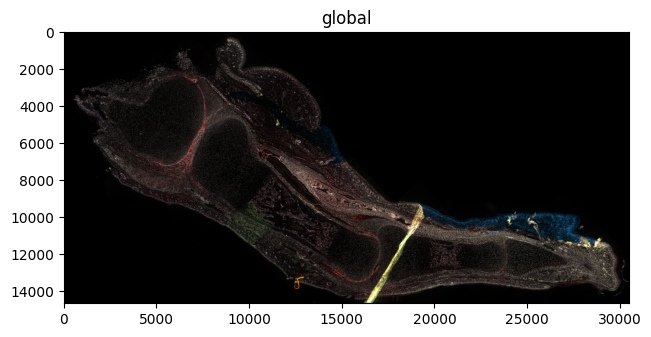

In [6]:
sdata.pl.render_images(IMAGE_KEY).pl.show(coordinate_systems="global")

## 6. Option B – Polygon drawing with a Shapes layer

1. Run the cell below – napari opens.
2. Select the **Shapes** layer and draw polygons or rectangles around regions of interest.
3. To assign class IDs **before closing**, run (in another cell or the napari console):
   ```python
   # Example: assign class IDs matching the order shapes were drawn
   layer.features["class_id"] = [1, 2, 1, 3, ...]
   ```
   If you skip this step every polygon is assigned class `1`.
4. Close the viewer; polygons are stored in `sdata.shapes` and rasterized to `sdata.labels`.

> Skip this section if you already annotated with Option A.

In [7]:
SHAPES_KEY = "shapes_semantic"
LABELS_FROM_SHAPES_KEY = "labels_from_shapes"

CLASS_LABELS = {
    1:  "artefact",
    2:  "epidermis",
    3:  "dermis",
    4:  "nail_matrix",
    5:  "adipose_tissue",
    6:  "bone",
    7:  "cartilage",
    8:  "vascular_structure",
    9:  "dense_regular_connective_tissue",
    10: "muscle",
    11: "background",
    12: "synovial_cavity",
    13: "bone_marrow",
    14: "other",
    15: "organelle"
}

run_annotation_session(
    sdata,
    image_key=IMAGE_KEY,
    mode="shapes",
    shapes_element_name=SHAPES_KEY,
    labels_element_name=LABELS_FROM_SHAPES_KEY,
    scale_factors=[2, 2],
    class_labels=CLASS_LABELS,
)

if SHAPES_KEY in sdata.shapes:
    print(f"\nShapes stored ({len(sdata.shapes[SHAPES_KEY])} polygons):")
    print(sdata.shapes[SHAPES_KEY][["class_id", "geometry"]].to_string())
if LABELS_FROM_SHAPES_KEY in sdata.labels:
    print(f"\nRasterized labels '{LABELS_FROM_SHAPES_KEY}':")
    print(sdata.labels[LABELS_FROM_SHAPES_KEY])


[napari] Draw polygons/rectangles on the image.
After each polygon: press T (or click 'Tag last polygon') to
assign the current class ID, then draw the next polygon.
Close the viewer when done.



c:\Users\mcowan\Documents\napari_spatial_data\.venv\Lib\site-packages\vispy\geometry\triangulation.py:720: RuntimeWarning: overflow encountered in multiply
  f = (l2 * p).sum(axis=-1)  # l2 dot p
c:\Users\mcowan\Documents\napari_spatial_data\.venv\Lib\site-packages\numpy\_core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
c:\Users\mcowan\Documents\napari_spatial_data\.venv\Lib\site-packages\vispy\geometry\triangulation.py:720: RuntimeWarning: overflow encountered in multiply
  f = (l2 * p).sum(axis=-1)  # l2 dot p
c:\Users\mcowan\Documents\napari_spatial_data\.venv\Lib\site-packages\numpy\_core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
c:\Users\mcowan\Documents\napari_spatial_data\.venv\Lib\site-packages\vispy\geometry\triangulation.py:720: RuntimeWarning: overflow encountered in multiply
  f = (l2 * p).sum(axis=

Stored 'shapes_semantic' in sdata.shapes  (n_shapes=645, classes=[1, 2, 3, 4, 6, 8, 9, 10, 12, 13, 14, 15])
Rasterized 'shapes_semantic' → 'labels_from_shapes'  (shape=(14636, 30506), unique classes=[0, 1, 2, 3, 4, 6, 8, 9, 10, 12, 13, 14, 15])


In [8]:
sdata

c:\Users\mcowan\Documents\napari_spatial_data\.venv\Lib\site-packages\zarr\core\group.py:3535: ZarrUserWarning: Object at zmetadata is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


SpatialData object, with associated Zarr store: G:\GROVe\processed\spatialdata_objects\17825\SpatialData_17825_300_processed_015.zarr
├── Images
│     └── 'raw': DataTree[cyx] (5, 14636, 30506), (5, 7318, 15253), (5, 3659, 7626), (5, 1829, 3813)
├── Labels
│     └── 'labels_from_shapes': DataTree[yx] (14636, 30506), (7318, 15253), (3659, 7626)
├── Points
│     └── 'joint_centroids': DataFrame with shape: (<Delayed>, 3) (2D points)
└── Shapes
      └── 'shapes_semantic': GeoDataFrame shape: (645, 2) (2D shapes)
with coordinate systems:
    ▸ 'global', with elements:
        raw (Images), labels_from_shapes (Labels), joint_centroids (Points), shapes_semantic (Shapes)
with the following elements not in the Zarr store:
    ▸ labels_from_shapes (Labels)
    ▸ shapes_semantic (Shapes)

## 8. Rasterize Shapes → Labels (Option B post-processing)

If you used Option B and want a raster version of the shapes *with* class IDs burned in,
run the cell below.  This step is performed automatically by `run_annotation_session` in
shapes mode, but you can re-run it any time (e.g. after editing `class_id` values).

In [9]:
import rasterio

# Only run if you used Option B (shapes annotation)
if SHAPES_KEY in sdata.shapes:
    rasterize_shapes_to_labels(
        sdata,
        shapes_key=SHAPES_KEY,
        image_key=IMAGE_KEY,
        element_name=LABELS_FROM_SHAPES_KEY,
        class_column="class_id",
        scale_factors=[2, 2, 2],
    )
    print(sdata.labels[LABELS_FROM_SHAPES_KEY])
else:
    print(f"No shapes found under key '{SHAPES_KEY}'. Run Option B first.")

Rasterized 'shapes_semantic' → 'labels_from_shapes'  (shape=(14636, 30506), unique classes=[0, 1, 2, 3, 4, 6, 8, 9, 10, 12, 13, 14, 15])
<xarray.DataTree>
Group: /
├── Group: /scale0
│       Dimensions:  (y: 14636, x: 30506)
│       Coordinates:
│         * y        (y) float64 117kB 0.5 1.5 2.5 3.5 ... 1.463e+04 1.463e+04 1.464e+04
│         * x        (x) float64 244kB 0.5 1.5 2.5 3.5 ... 3.05e+04 3.05e+04 3.051e+04
│       Data variables:
│           image    (y, x) int32 2GB dask.array<chunksize=(256, 256), meta=np.ndarray>
├── Group: /scale1
│       Dimensions:  (y: 7318, x: 15253)
│       Coordinates:
│         * y        (y) float64 59kB 1.0 3.0 5.0 7.0 ... 1.463e+04 1.463e+04 1.464e+04
│         * x        (x) float64 122kB 1.0 3.0 5.0 7.0 ... 3.05e+04 3.05e+04 3.05e+04
│       Data variables:
│           image    (y, x) int32 446MB dask.array<chunksize=(256, 256), meta=np.ndarray>
├── Group: /scale2
│       Dimensions:  (y: 3659, x: 7626)
│       Coordinates:
│         * y    

In [10]:
sdata

c:\Users\mcowan\Documents\napari_spatial_data\.venv\Lib\site-packages\zarr\core\group.py:3535: ZarrUserWarning: Object at zmetadata is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


SpatialData object, with associated Zarr store: G:\GROVe\processed\spatialdata_objects\17825\SpatialData_17825_300_processed_015.zarr
├── Images
│     └── 'raw': DataTree[cyx] (5, 14636, 30506), (5, 7318, 15253), (5, 3659, 7626), (5, 1829, 3813)
├── Labels
│     └── 'labels_from_shapes': DataTree[yx] (14636, 30506), (7318, 15253), (3659, 7626), (1829, 3813)
├── Points
│     └── 'joint_centroids': DataFrame with shape: (<Delayed>, 3) (2D points)
└── Shapes
      └── 'shapes_semantic': GeoDataFrame shape: (645, 2) (2D shapes)
with coordinate systems:
    ▸ 'global', with elements:
        raw (Images), labels_from_shapes (Labels), joint_centroids (Points), shapes_semantic (Shapes)
with the following elements not in the Zarr store:
    ▸ labels_from_shapes (Labels)
    ▸ shapes_semantic (Shapes)

Now, create table from shapes layer

In [11]:
measure_label_morphology(sdata, labels_key=LABELS_FROM_SHAPES_KEY, 
                         shapes_key=SHAPES_KEY,
                         image_key= "raw",
                         element_name="tissue_annotation_morphology_v2")

# Access results
sdata.tables["tissue_annotation_morphology_v2"].obs  # pandas DataFrame with all features


c:\Users\mcowan\Documents\napari_spatial_data\.venv\Lib\site-packages\spatialdata\models\models.py:1206: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(adata)


Measured morphology for 'labels_from_shapes' → table 'tissue_annotation_morphology_v2'  (n_instances=860, n_features=32)


,area,perimeter,eccentricity,solidity,extent,orientation,axis_major_length,axis_minor_length,centroid-0,centroid-1,...,2_min_intensity,3_mean_intensity,3_max_intensity,3_min_intensity,4_mean_intensity,4_max_intensity,4_min_intensity,class_id,region,instance_id
instance_id,,,,,,,,,,,,,,,,,,,,,
1,227956.0,2484.816593,0.887727,0.814812,0.425236,1.112584,875.402637,403.009347,2717.784270,6896.591531,...,0.0,7759.778220,65476.0,590.0,1338.739871,17734.0,0.0,1,shapes_semantic,1
2,4871976.0,20991.385556,0.988588,0.553217,0.176729,1.026644,7878.663539,1186.885398,5159.031491,12601.994872,...,0.0,735.261021,65465.0,0.0,442.450051,65202.0,0.0,1,shapes_semantic,2
3,600158.0,4203.229940,0.580606,0.845078,0.693193,0.853175,1040.315842,847.008859,4162.222117,2386.568864,...,0.0,1335.031753,24105.0,0.0,2006.622476,40943.0,0.0,1,shapes_semantic,3
4,769.0,362.183766,0.999419,0.812896,0.214146,-0.086205,184.915282,6.300890,4400.814044,7578.821847,...,0.0,11196.639792,33853.0,3888.0,720.154746,1460.0,4.0,1,shapes_semantic,4
5,1322.0,356.355339,0.997371,0.916147,0.484249,-0.071016,156.290847,11.325847,4532.785930,7596.228442,...,0.0,11907.381997,26226.0,4778.0,1255.027988,3846.0,58.0,1,shapes_semantic,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
856,4486.0,267.095454,0.660247,0.980118,0.769600,-1.484397,88.018790,66.106380,12111.241864,29117.054837,...,0.0,1301.528756,3522.0,601.0,520.168747,4161.0,0.0,15,shapes_semantic,856
857,9283.0,371.605122,0.669840,0.982224,0.735928,0.950590,126.364661,93.826499,12527.264139,29107.017020,...,0.0,2083.783260,22598.0,805.0,666.534310,4409.0,0.0,15,shapes_semantic,857
858,25247.0,950.011327,0.981364,0.759103,0.278376,0.629143,449.376271,86.352265,12851.676674,29158.387016,...,0.0,1333.789876,10061.0,440.0,376.075930,5222.0,0.0,15,shapes_semantic,858


INFO     Rasterizing image for faster rendering.                                                                   
INFO     Your image has 5 channels. Sampling categorical colors and using multichannel strategy 'stack' to render. 
INFO     Rasterizing image for faster rendering.                                                                   


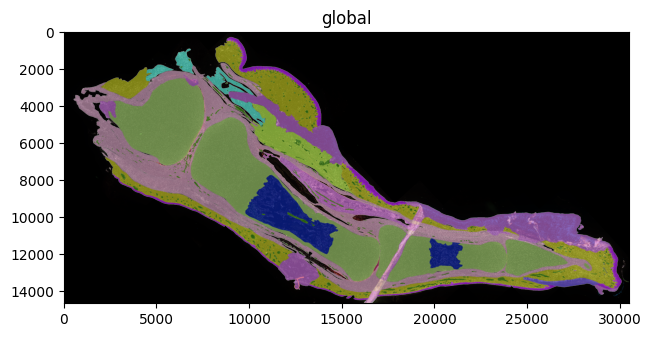

In [12]:
import spatialdata_plot

sdata.pl.render_images(IMAGE_KEY).pl.render_labels(LABELS_FROM_SHAPES_KEY).pl.show(coordinate_systems="global")

## 9. Save to Zarr / write individual elements

`sdata.write()` persists the entire SpatialData object (images, labels, shapes, …)
to a single Zarr store on disk.  Use `overwrite=True` to replace an existing store.

In [ ]:
# ZARR_PATH = "../data/annotated.zarr"   # change to your desired output path

# sdata.write(ZARR_PATH, overwrite=False)
# print(f"Saved → {ZARR_PATH!r}")

c:\Users\mcowan\Documents\napari_spatial_data\.venv\Lib\site-packages\ome_zarr\writer.py:319: FutureWarning: Passing storage-related arguments via **kwargs is deprecated. Please use the 'zarr_store_kwargs' parameter instead. **kwargs will be removed in a future version.
  da_delayed = da.to_zarr(


Saved → '../data/annotated.zarr'


In [13]:
import numpy as np

KEY = "labels_from_shapes"

labels = sdata.labels[KEY]["scale0"].ds["image"].values

np.save(f"../data/IF/{SAMPLE_ID}_{KEY}.npy", labels)

In [14]:
import geopandas as gpd

sdata.shapes["shapes_semantic"].to_parquet(f"../data/IF/{SAMPLE_ID}_shapes_semantic.parquet")

## Tips & next steps

| Goal | How |
|---|---|
| Change brush size in napari | `Labels` layer → scroll-wheel or the *Brush size* slider |
| Review annotations with a custom colormap | Call `class_id_colormap(n_classes=3)` and pass the result to `viewer.add_labels(..., color=colormap)` |
| Export only one element | `sdata.write_element("labels_semantic")` after the store is created |
| Work with real data | Replace `make_demo_sdata()` with `spatialdata.read_zarr(...)` |
| Add a cell-segmentation table | Attach an `AnnData` table via `sdata.tables["cells"] = ...` |

## 10. Mask fine-tuning / correction

Use this section to load an **existing** mask (from a `.npy` file **or** from a
`sdata.labels` element) into napari as an editable layer, paint corrections over it,
then save the refined result.

**Workflow:**
1. Run **one** of the two "load" cells below (Option A or Option B) to populate `mask_to_refine`.
2. Run the **refinement session** cell — napari opens with your mask pre-loaded.
3. Paint corrections:
   - Use label `0` (eraser) to remove errors.
   - Paint a class integer to fill missing regions or fix boundaries.
4. Close the viewer — the corrected mask is saved automatically.
5. Run the **verify** cell to confirm the result.

In [ ]:
# --- Option A: load mask from a .npy file ---
# Adjust NPY_MASK_PATH to point to your file.
NPY_MASK_PATH = f"../data/IF/{SAMPLE_ID}_labels_from_shapes.npy"

mask_to_refine = np.load(NPY_MASK_PATH)

print(f"Loaded mask from: {NPY_MASK_PATH!r}")
print(f"  shape  : {mask_to_refine.shape}")
print(f"  dtype  : {mask_to_refine.dtype}")
print(f"  classes: {np.unique(mask_to_refine).tolist()}")

In [ ]:
# --- Option B: load mask from an existing sdata.labels element ---
# Set SOURCE_LABELS_KEY to the key you want to refine.
SOURCE_LABELS_KEY = LABELS_FROM_SHAPES_KEY  # e.g. "labels_from_shapes"

element = sdata.labels[SOURCE_LABELS_KEY]
try:
    mask_to_refine = np.asarray(element["scale0"].ds["image"].values)
except (TypeError, AttributeError, KeyError):
    mask_to_refine = np.asarray(element.values)

print(f"Loaded mask from sdata.labels[{SOURCE_LABELS_KEY!r}]")
print(f"  shape  : {mask_to_refine.shape}")
print(f"  dtype  : {mask_to_refine.dtype}")
print(f"  classes: {np.unique(mask_to_refine).tolist()}")

In [ ]:
# --- Run refinement session ---
# Requires mask_to_refine to be set by running Option A or Option B above.

REFINED_LABELS_KEY = "labels_refined_v1"                              # output key in sdata
REFINED_NPY_PATH   = f"../data/IF/{SAMPLE_ID}_{REFINED_LABELS_KEY}.npy"  # set to None to skip

run_refinement_session(
    sdata,
    image_key=IMAGE_KEY,
    mask_source=mask_to_refine,
    labels_element_name=REFINED_LABELS_KEY,
    scale_factors=[2, 2, 2],
    save_npy_path=REFINED_NPY_PATH,
)

In [ ]:
# --- Verify result ---
if REFINED_LABELS_KEY in sdata.labels:
    refined_arr = np.asarray(
        sdata.labels[REFINED_LABELS_KEY]["scale0"].ds["image"].values
    )
    print(f"Classes before refinement : {np.unique(mask_to_refine).tolist()}")
    print(f"Classes after  refinement : {np.unique(refined_arr).tolist()}")
    print(sdata.labels[REFINED_LABELS_KEY])
else:
    print(f"'{REFINED_LABELS_KEY}' not found in sdata.labels — did you close the viewer?")

In [ ]:
# --- Persist refined labels to the Zarr store (optional) ---
# sdata.write_element(REFINED_LABELS_KEY)
# print(f"Written '{REFINED_LABELS_KEY}' to the Zarr store.")